In [1]:
from __future__ import annotations
import hashlib, json, re, shutil, unicodedata
from pathlib import Path
import joblib
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from IPython.display import display
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline

SEED = 42
RUN_CLEANLAB = True
CLEANLAB_REMOVE_IDS = [int(line) for line in Path("cleanlab_remove_ids.txt").read_text(encoding="utf-8").splitlines() if line.strip() and not line.startswith("#")]
SHORT_LEN = 12
REPO = "Cleanlab/amazon-reviews"
REVISION = "bca513e6ecd76a4051dfb80445ff0b0083c6be35"
EXPECTED_SHA256 = {
    "train.csv": "11a690807059fc599b299c97779d9a06afce8a7fcd81b60eca689c61b37a3890",
    "test.csv": "7304389d01c4f2fdbe4491d8fe6086f2beaa90727be2c85fad2ca11ec3d979b1",
}
AUDIT_COLS = ["split_source", "source_row_id", "stage", "reason", "action"]
DUP_COLS = ["review_text_clean", "label"]
OUT = Path("processed")
OUT.mkdir(exist_ok=True)
quarantine, issues, norm_changes = [], [], []


In [2]:
try:
    train_path = hf_hub_download(REPO, "train.csv", repo_type="dataset", revision=REVISION)
    test_path = hf_hub_download(REPO, "test.csv", repo_type="dataset", revision=REVISION)
except Exception:
    try:
        train_path = hf_hub_download(REPO, "train.csv", repo_type="dataset", revision=REVISION, local_files_only=True)
        test_path = hf_hub_download(REPO, "test.csv", repo_type="dataset", revision=REVISION, local_files_only=True)
    except Exception:
        train_path, test_path = str(OUT / "train_raw.csv"), str(OUT / "test_raw.csv")
        assert Path(train_path).is_file() and Path(test_path).is_file(), "offline fallback CSVs missing"
        assert hashlib.sha256(Path(train_path).read_bytes()).hexdigest() == EXPECTED_SHA256["train.csv"], "train_raw.csv hash mismatch"
        assert hashlib.sha256(Path(test_path).read_bytes()).hexdigest() == EXPECTED_SHA256["test.csv"], "test_raw.csv hash mismatch"
train_raw = pd.read_csv(train_path)
test_raw = pd.read_csv(test_path)
n_test_raw = len(test_raw)
input_hashes = {
    "train.csv": hashlib.sha256(Path(train_path).read_bytes()).hexdigest(),
    "test.csv": hashlib.sha256(Path(test_path).read_bytes()).hexdigest(),
}
assert input_hashes == EXPECTED_SHA256, input_hashes


In [3]:
for src, name in ((train_path, "train_raw.csv"), (test_path, "test_raw.csv")):
    dst = (OUT / name).resolve()
    if Path(src).resolve() != dst:
        shutil.copyfile(src, dst)
assert hashlib.sha256((OUT / "train_raw.csv").read_bytes()).hexdigest() == EXPECTED_SHA256["train.csv"]
assert hashlib.sha256((OUT / "test_raw.csv").read_bytes()).hexdigest() == EXPECTED_SHA256["test.csv"]
train_work = train_raw.copy()
test_clean = test_raw.copy()


In [4]:
src_cols = ["review_text", "label"]
assert list(train_work.columns) == src_cols, list(train_work.columns)
assert list(test_clean.columns) == src_cols, list(test_clean.columns)
assert pd.api.types.is_string_dtype(train_work["review_text"]) or train_work["review_text"].dtype == object
assert pd.api.types.is_string_dtype(train_work["label"]) or train_work["label"].dtype == object
assert pd.api.types.is_string_dtype(test_clean["review_text"]) or test_clean["review_text"].dtype == object
assert pd.api.types.is_string_dtype(test_clean["label"]) or test_clean["label"].dtype == object


In [5]:
train_work["split_source"] = "train"
train_work["source_row_id"] = range(len(train_work))
test_clean["split_source"] = "test"
test_clean["source_row_id"] = range(len(test_clean))


In [6]:
print({"revision": REVISION, "train": train_work.shape, "test": test_clean.shape})
print(train_work.dtypes)
display(train_work.head())
display(train_work["review_text"].str.len().describe().to_frame("char_len"))


{'revision': 'bca513e6ecd76a4051dfb80445ff0b0083c6be35', 'train': (5000, 4), 'test': (1000, 4)}
review_text        str
label              str
split_source       str
source_row_id    int64
dtype: object


,review_text,label,split_source,source_row_id
0,Excellent product! I love reading through the magazine and learning about the cool new products out there and the cool programs!,positive,train,0
1,"If you into gaming, into the latest PC tech info, like reviews of hardware rated 1 thru 10, chomp PC builds, get this rag. @ $12 bucks for 2 years its worth every penny",positive,train,1
2,Great Mag..!!,positive,train,2
3,"Extremely similar to GQ, same publisher. You aren't going to get anything from this magazine that you don't get from GQ. Similar to GQ, lots of ads and minimal content.",positive,train,3
4,it is great read and great ideas for today's men .. great price.. buy it today.. go for it :),positive,train,4


,char_len
count,5000.000000
mean,92.524000
std,47.672167
min,9.000000
25%,49.000000
50%,97.000000
75%,132.000000
max,179.000000


,n,len_mean,len_median
label,,,
negative,1908,96.730608,101.0
positive,3092,89.928202,93.0


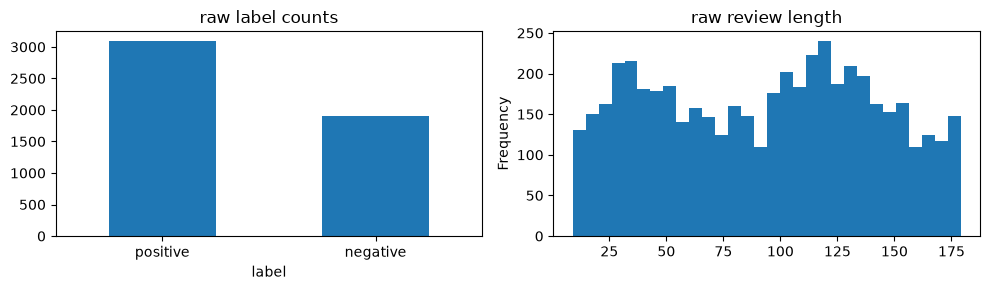

In [7]:
raw_eda = train_work.assign(char_len=train_work["review_text"].str.len())
display(raw_eda.groupby("label").agg(n=("review_text", "size"), len_mean=("char_len", "mean"), len_median=("char_len", "median")))
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
raw_eda["label"].value_counts().plot(kind="bar", ax=ax[0], title="raw label counts", rot=0)
raw_eda["char_len"].plot(kind="hist", bins=30, ax=ax[1], title="raw review length")
plt.tight_layout(); fig.savefig(OUT / "eda_raw.png", dpi=150, bbox_inches="tight"); plt.show()


In [8]:
miss_tr = train_work["label"].isna() | train_work["review_text"].isna()
miss_te = test_clean["label"].isna() | test_clean["review_text"].isna()
for df, m in ((train_work, miss_tr), (test_clean, miss_te)):
    for r in df.loc[m, ["split_source", "source_row_id"]].itertuples(index=False):
        quarantine.append({"split_source": r.split_source, "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "empty_or_missing", "action": "removed"})
train_work = train_work.loc[~miss_tr].copy()
test_clean = test_clean.loc[~miss_te].copy()


In [9]:
train_work["label"] = train_work["label"].astype(str).str.strip().str.lower()
test_clean["label"] = test_clean["label"].astype(str).str.strip().str.lower()
blank_tr = train_work["label"].eq("")
blank_te = test_clean["label"].eq("")
for df, m in ((train_work, blank_tr), (test_clean, blank_te)):
    for r in df.loc[m, ["split_source", "source_row_id"]].itertuples(index=False):
        quarantine.append({"split_source": r.split_source, "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "empty_or_missing", "action": "removed"})
train_work = train_work.loc[~blank_tr].copy()
test_clean = test_clean.loc[~blank_te].copy()
allowed = {"positive", "negative"}
bad_tr = ~train_work["label"].isin(allowed)
bad_te = ~test_clean["label"].isin(allowed)
for df, m in ((train_work, bad_tr), (test_clean, bad_te)):
    for r in df.loc[m, ["split_source", "source_row_id"]].itertuples(index=False):
        quarantine.append({"split_source": r.split_source, "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "invalid_label", "action": "removed"})
train_work = train_work.loc[~bad_tr].copy()
test_clean = test_clean.loc[~bad_te].copy()


In [10]:
for df in (train_work, test_clean):
    df["review_text_clean"] = df["review_text"].fillna("").map(lambda s: re.sub(r"\s+", " ", unicodedata.normalize("NFKC", str(s))).strip())
    changed = df["review_text"].astype(str) != df["review_text_clean"]
    for r in df.loc[changed, ["split_source", "source_row_id", "review_text", "review_text_clean"]].itertuples(index=False):
        norm_changes.append({"split_source": r.split_source, "source_row_id": int(r.source_row_id), "review_text": r.review_text, "review_text_clean": r.review_text_clean})


In [11]:
empty_tr = train_work["review_text_clean"].eq("")
empty_te = test_clean["review_text_clean"].eq("")
for df, m in ((train_work, empty_tr), (test_clean, empty_te)):
    for r in df.loc[m, ["split_source", "source_row_id"]].itertuples(index=False):
        quarantine.append({"split_source": r.split_source, "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "empty_or_missing", "action": "removed"})
train_work = train_work.loc[~empty_tr].copy()
test_clean = test_clean.loc[~empty_te].copy()


In [12]:
for df in (train_work, test_clean):
    short = df["review_text_clean"].str.len() < SHORT_LEN
    for r in df.loc[short, ["split_source", "source_row_id"]].itertuples(index=False):
        issues.append({"split_source": r.split_source, "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "short_review", "action": "retained_flagged"})


In [13]:
nlab = train_work.groupby("review_text_clean")["label"].nunique()
conflict_txt = set(nlab[nlab > 1].index)
c_tr = train_work["review_text_clean"].isin(conflict_txt)
for r in train_work.loc[c_tr, ["source_row_id"]].itertuples(index=False):
    quarantine.append({"split_source": "train", "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "label_conflict", "action": "removed"})
train_work = train_work.loc[~c_tr].copy()


In [14]:
nlab_te = test_clean.groupby("review_text_clean")["label"].nunique()
conflict_te = set(nlab_te[nlab_te > 1].index)
for r in test_clean.loc[test_clean["review_text_clean"].isin(conflict_te), ["source_row_id"]].itertuples(index=False):
    issues.append({"split_source": "test", "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "label_conflict", "action": "retained_flagged"})


In [15]:
merged = train_work.merge(test_clean[["review_text_clean", "label"]], on="review_text_clean", suffixes=("_tr", "_te"))
cross_conf = set(merged.loc[merged["label_tr"] != merged["label_te"], "review_text_clean"])
xc = train_work["review_text_clean"].isin(cross_conf)
for r in train_work.loc[xc, ["source_row_id"]].itertuples(index=False):
    quarantine.append({"split_source": "train", "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "cross_split_label_conflict", "action": "removed"})
train_work = train_work.loc[~xc].copy()


In [16]:
dup_tr = train_work.duplicated(DUP_COLS, keep="first")
for r in train_work.loc[dup_tr, ["source_row_id"]].itertuples(index=False):
    quarantine.append({"split_source": "train", "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "duplicate", "action": "removed"})
train_work = train_work.loc[~dup_tr].copy()


In [17]:
dup_te = test_clean.duplicated(DUP_COLS, keep="first")
for r in test_clean.loc[dup_te, ["source_row_id"]].itertuples(index=False):
    issues.append({"split_source": "test", "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "duplicate", "action": "retained_flagged"})


In [18]:
ov = train_work["review_text_clean"].isin(set(test_clean["review_text_clean"]))
for r in train_work.loc[ov, ["source_row_id"]].itertuples(index=False):
    quarantine.append({"split_source": "train", "source_row_id": int(r.source_row_id), "stage": "etl", "reason": "cross_split_duplicate", "action": "removed"})
train_work = train_work.loc[~ov].copy()


In [19]:
train_clean, val_clean = train_test_split(train_work, test_size=0.2, random_state=SEED, stratify=train_work["label"])
train_clean, val_clean = train_clean.copy(), val_clean.copy()


In [20]:
s_tr, s_va, s_te = set(train_clean["review_text_clean"]), set(val_clean["review_text_clean"]), set(test_clean["review_text_clean"])
assert not (s_tr & s_va), "train/val overlap"
assert not (s_tr & s_te), "train/test overlap"
assert not (s_va & s_te), "val/test overlap"
print({"N_test_raw": n_test_raw, "N_test_clean": len(test_clean)})


{'N_test_raw': 1000, 'N_test_clean': 1000}


,train_clean,val_clean
positive,2474,618
negative,1526,382


label,negative,positive
split,,
train,1526,2474
val,382,618


stage  reason      
etl    short_review    57
Name: flagged, dtype: int64

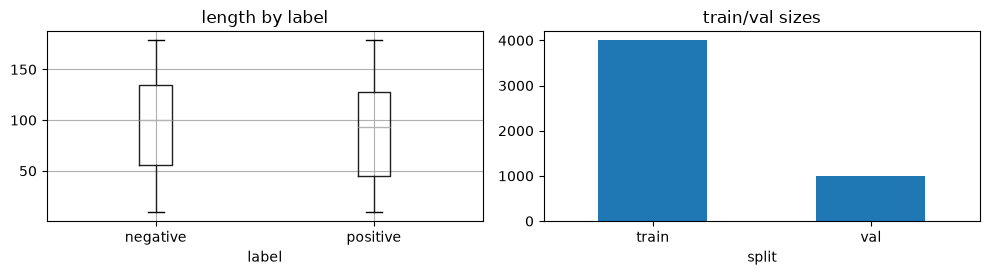

In [21]:
dev_eda = pd.concat([train_clean.assign(split="train"), val_clean.assign(split="val")], ignore_index=True)
dev_eda = dev_eda.assign(char_len=dev_eda["review_text_clean"].str.len())
dist_dev = {"train_clean": train_clean["label"].value_counts().to_dict(), "val_clean": val_clean["label"].value_counts().to_dict()}
display(pd.DataFrame(dist_dev).fillna(0).astype(int))
display(dev_eda.groupby(["split", "label"]).size().unstack(fill_value=0))
if quarantine: display(pd.DataFrame(quarantine).groupby(["stage", "reason"]).size().rename("removed"))
if issues: display(pd.DataFrame(issues).groupby(["stage", "reason"]).size().rename("flagged"))
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
dev_eda.boxplot(column="char_len", by="label", ax=ax[0]); ax[0].set_title("length by label"); ax[0].set_xlabel("label")
dev_eda["split"].value_counts().plot(kind="bar", ax=ax[1], title="train/val sizes", rot=0)
plt.suptitle(""); plt.tight_layout(); fig.savefig(OUT / "eda_clean.png", dpi=150, bbox_inches="tight"); plt.show()


In [22]:
test_primary = test_clean.copy()
test_dedup = test_clean.drop_duplicates(DUP_COLS, keep="first").copy()


In [23]:
keep = ["review_text", "review_text_clean", "label", "split_source", "source_row_id"]
train_clean[keep].to_csv(OUT / "train_clean.csv", index=False)
val_clean[keep].to_csv(OUT / "val_clean.csv", index=False)
test_clean[keep].to_csv(OUT / "test_clean.csv", index=False)
test_primary[keep].to_csv(OUT / "test_primary.csv", index=False)
test_dedup[keep].to_csv(OUT / "test_dedup.csv", index=False)
pd.DataFrame(norm_changes, columns=["split_source", "source_row_id", "review_text", "review_text_clean"]).to_csv(OUT / "normalization_changes.csv", index=False)
assert train_clean["label"].isin(allowed).all() and val_clean["label"].isin(allowed).all() and test_clean["label"].isin(allowed).all()
assert train_clean["review_text_clean"].notna().all() and (train_clean["review_text_clean"] != "").all()


In [24]:
train_dev = train_clean.copy()
enc = {"negative": 0, "positive": 1}
train_dev["y"] = train_dev["label"].map(enc)
val_clean["y"] = val_clean["label"].map(enc)
test_primary["y"] = test_primary["label"].map(enc)
test_dedup["y"] = test_dedup["label"].map(enc)


In [25]:
train_dev = train_clean.copy()
train_dev["y"] = train_dev["label"].map(enc)
quarantine[:] = [q for q in quarantine if q["stage"] != "cleanlab"]
issues[:] = [i for i in issues if i["stage"] != "cleanlab"]
if RUN_CLEANLAB:
    from cleanlab.filter import find_label_issues
    baseline = Pipeline([("tfidf", TfidfVectorizer(lowercase=True)), ("clf", LogisticRegression(max_iter=2000, random_state=SEED))])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    pred_probs = cross_val_predict(baseline, train_dev["review_text_clean"], train_dev["y"], cv=cv, method="predict_proba")
    issue_mask = find_label_issues(labels=train_dev["y"].to_numpy(), pred_probs=pred_probs, n_jobs=1)
    suspected = train_dev.loc[issue_mask, ["source_row_id", "review_text_clean", "label"]]
    display(suspected)
    print("edit CLEANLAB_REMOVE_IDS in setup, then restart kernel and Run All")
    suspected_ids = set(int(x) for x in train_dev.loc[issue_mask, "source_row_id"])
    requested = set(int(x) for x in CLEANLAB_REMOVE_IDS)
    unexpected = requested - suspected_ids
    assert not unexpected, f"CLEANLAB_REMOVE_IDS not flagged: {sorted(unexpected)}"
    remove = requested & suspected_ids
    for r in train_dev.loc[issue_mask, ["source_row_id"]].itertuples(index=False):
        rid = int(r.source_row_id)
        if rid in remove:
            quarantine.append({"split_source": "train", "source_row_id": rid, "stage": "cleanlab", "reason": "suspected_label_issue", "action": "removed"})
        else:
            issues.append({"split_source": "train", "source_row_id": rid, "stage": "cleanlab", "reason": "suspected_label_issue", "action": "retained_flagged"})
    if remove:
        train_dev = train_dev.loc[~train_dev["source_row_id"].isin(remove)].copy()
        print({"train_dev": len(train_dev), "label": train_dev["label"].value_counts().to_dict()})
        assert train_dev["y"].notna().all() and len(train_dev) > 0
else:
    assert not CLEANLAB_REMOVE_IDS, "CLEANLAB_REMOVE_IDS requires RUN_CLEANLAB=True"
    print("RUN_CLEANLAB=False; skip data-quality loop")

train_dev_dist = train_dev["label"].value_counts().to_dict()
train_dev_hash = hashlib.sha256(
    train_dev[["source_row_id", "review_text_clean", "label"]].sort_values("source_row_id").to_csv(index=False).encode()
).hexdigest()
train_dev[keep].to_csv(OUT / "train_dev.csv", index=False)


,source_row_id,review_text_clean,label
55,55,i don't like that its a running subscribtion,positive
3108,3108,Tooo many ads now.,positive
1090,1090,Not my kind of travel. Too spendy.,positive
1801,1801,I am still waiting on my first edition of the magazine to arrive. It has been 72 days since I ordered.,positive
3708,3708,I don't remember this being full of advertising.,positive
...,...,...,...
3264,3264,It is healthy eating and habits. Unfortunately sick want a subscription delivery but I don't see it on Amazon. I don't want a digital read.,positive
800,800,"ite's popular mechanics, just what I expecterd",positive
4544,4544,Only evening listings! Not much info on the shows. There must be something better!,positive
4089,4089,very informative great for women over 35,negative


edit CLEANLAB_REMOVE_IDS in setup, then restart kernel and Run All
{'train_dev': 3626, 'label': {'positive': 2192, 'negative': 1434}}


In [26]:
pd.DataFrame(quarantine, columns=AUDIT_COLS).to_csv(OUT / "quarantine.csv", index=False)
pd.DataFrame(issues, columns=AUDIT_COLS).to_csv(OUT / "issues.csv", index=False)


In [27]:
candidates = {
    "tfidf_lr": Pipeline([("tfidf", TfidfVectorizer(lowercase=True, min_df=2)), ("clf", LogisticRegression(max_iter=2000, random_state=SEED))]),
    "tfidf_lr_balanced": Pipeline([("tfidf", TfidfVectorizer(lowercase=True, min_df=2)), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED))]),
    "tfidf_ngram_lr": Pipeline([("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2)), ("clf", LogisticRegression(max_iter=2000, random_state=SEED))]),
}
val_scores = {}
fitted = {}
for name, pipe in candidates.items():
    model = clone(pipe)
    model.fit(train_dev["review_text_clean"], train_dev["y"])
    pred = model.predict(val_clean["review_text_clean"])
    val_scores[name] = f1_score(val_clean["y"], pred, average="macro")
    fitted[name] = model
    print(name, val_scores[name], classification_report(val_clean["y"], pred, target_names=["negative", "positive"]))
best_name = max(val_scores, key=val_scores.get)
display(pd.DataFrame({"f1_macro": val_scores}).sort_values("f1_macro", ascending=False))
print("selected", best_name, val_scores[best_name])


tfidf_lr 0.824094084535357               precision    recall  f1-score   support

    negative       0.76      0.81      0.79       382
    positive       0.88      0.84      0.86       618

    accuracy                           0.83      1000
   macro avg       0.82      0.83      0.82      1000
weighted avg       0.83      0.83      0.83      1000

tfidf_lr_balanced 0.8325510488159922               precision    recall  f1-score   support

    negative       0.74      0.88      0.81       382
    positive       0.92      0.81      0.86       618

    accuracy                           0.84      1000
   macro avg       0.83      0.85      0.83      1000
weighted avg       0.85      0.84      0.84      1000

tfidf_ngram_lr 0.8134570804565899               precision    recall  f1-score   support

    negative       0.75      0.80      0.77       382
    positive       0.87      0.84      0.85       618

    accuracy                           0.82      1000
   macro avg       0.81      0

,f1_macro
tfidf_lr_balanced,0.832551
tfidf_lr,0.824094
tfidf_ngram_lr,0.813457


selected tfidf_lr_balanced 0.8325510488159922


metrics_primary {'accuracy': 0.956, 'precision': 0.9594723934948797, 'recall': 0.9524982705681032, 'f1_macro': 0.955195490222434, 'confusion_matrix': [[411, 36], [8, 545]], 'class_counts': {'positive': 553, 'negative': 447}}
              precision    recall  f1-score   support

    negative       0.98      0.92      0.95       447
    positive       0.94      0.99      0.96       553

    accuracy                           0.96      1000
   macro avg       0.96      0.95      0.96      1000
weighted avg       0.96      0.96      0.96      1000

metrics_deduplicated {'accuracy': 0.956, 'precision': 0.9594723934948797, 'recall': 0.9524982705681032, 'f1_macro': 0.955195490222434, 'confusion_matrix': [[411, 36], [8, 545]], 'class_counts': {'positive': 553, 'negative': 447}}


,primary,deduplicated
accuracy,0.956,0.956
precision,0.959472,0.959472
recall,0.952498,0.952498
f1_macro,0.955195,0.955195


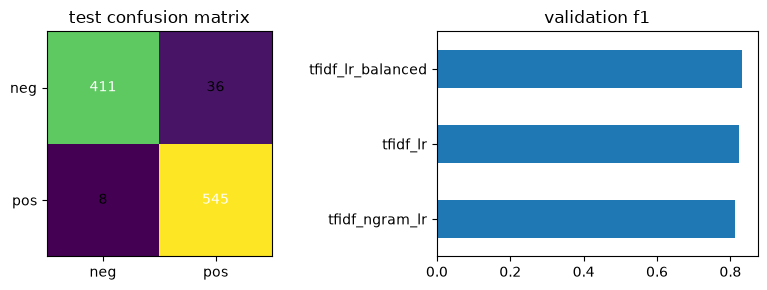

2029

In [28]:
train_final = pd.concat([train_dev, val_clean], ignore_index=True)
selected = clone(candidates[best_name])
selected.fit(train_final["review_text_clean"], train_final["y"])
joblib.dump(selected, OUT / "model.joblib")
pred_primary = selected.predict(test_primary["review_text_clean"])
pred_dedup = selected.predict(test_dedup["review_text_clean"])
metrics_primary = {
    "accuracy": accuracy_score(test_primary["y"], pred_primary),
    "precision": precision_score(test_primary["y"], pred_primary, average="macro"),
    "recall": recall_score(test_primary["y"], pred_primary, average="macro"),
    "f1_macro": f1_score(test_primary["y"], pred_primary, average="macro"),
    "confusion_matrix": confusion_matrix(test_primary["y"], pred_primary).tolist(),
    "class_counts": test_primary["label"].value_counts().to_dict(),
}
metrics_deduplicated = {
    "accuracy": accuracy_score(test_dedup["y"], pred_dedup),
    "precision": precision_score(test_dedup["y"], pred_dedup, average="macro"),
    "recall": recall_score(test_dedup["y"], pred_dedup, average="macro"),
    "f1_macro": f1_score(test_dedup["y"], pred_dedup, average="macro"),
    "confusion_matrix": confusion_matrix(test_dedup["y"], pred_dedup).tolist(),
    "class_counts": test_dedup["label"].value_counts().to_dict(),
}
print("metrics_primary", metrics_primary)
print(classification_report(test_primary["y"], pred_primary, target_names=["negative", "positive"]))
print("metrics_deduplicated", metrics_deduplicated)
display(pd.DataFrame({"primary": metrics_primary, "deduplicated": metrics_deduplicated}).loc[["accuracy", "precision", "recall", "f1_macro"]])
cm = confusion_matrix(test_primary["y"], pred_primary)
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].imshow(cm); ax[0].set_xticks([0, 1]); ax[0].set_yticks([0, 1]); ax[0].set_xticklabels(["neg", "pos"]); ax[0].set_yticklabels(["neg", "pos"])
for i in range(2):
    for j in range(2): ax[0].text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
ax[0].set_title("test confusion matrix")
pd.DataFrame({"f1_macro": val_scores}).sort_values("f1_macro", ascending=True).plot(kind="barh", ax=ax[1], legend=False, title="validation f1")
plt.tight_layout(); fig.savefig(OUT / "eda_results.png", dpi=150, bbox_inches="tight"); plt.show()
(OUT / "metrics.json").write_text(json.dumps({
    "revision": REVISION,
    "train_dev_hash": train_dev_hash,
    "selected": best_name,
    "model_params": {"tfidf": selected.named_steps["tfidf"].get_params(), "clf": selected.named_steps["clf"].get_params()},
    "val_scores": val_scores,
    "metrics_primary": metrics_primary,
    "metrics_deduplicated": metrics_deduplicated,
}, indent=2, default=str), encoding="utf-8")


,n
label,
positive,553
negative,447


,n,len_mean,len_median
label,,,
negative,447,94.035794,98.0
positive,553,91.301989,94.0


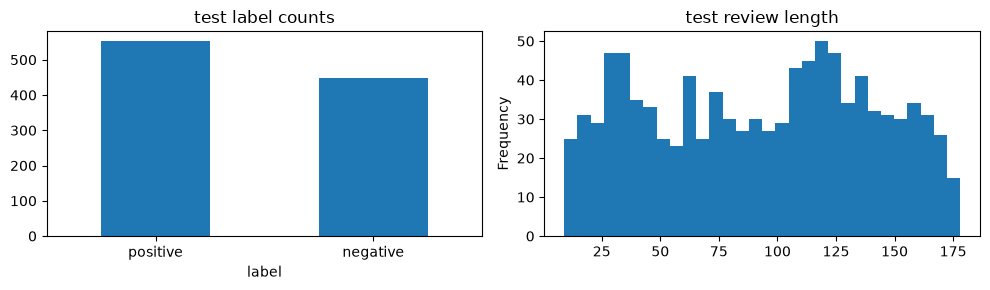

5783

In [29]:
test_eda = test_clean.assign(char_len=test_clean["review_text_clean"].str.len())
display(test_eda["label"].value_counts().to_frame("n"))
display(test_eda.groupby("label").agg(n=("review_text_clean", "size"), len_mean=("char_len", "mean"), len_median=("char_len", "median")))
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
test_eda["label"].value_counts().plot(kind="bar", ax=ax[0], title="test label counts", rot=0)
test_eda["char_len"].plot(kind="hist", bins=30, ax=ax[1], title="test review length")
plt.tight_layout(); fig.savefig(OUT / "eda_test.png", dpi=150, bbox_inches="tight"); plt.show()
dist = {**dist_dev, "train_dev": train_dev_dist, "test_clean": test_clean["label"].value_counts().to_dict()}
report = {
    "revision": REVISION,
    "seed": SEED,
    "input_hashes": input_hashes,
    "train_raw_archive_sha256": hashlib.sha256((OUT / "train_raw.csv").read_bytes()).hexdigest(),
    "test_raw_archive_sha256": hashlib.sha256((OUT / "test_raw.csv").read_bytes()).hexdigest(),
    "config": {"short_len": SHORT_LEN, "run_cleanlab": RUN_CLEANLAB, "cleanlab_remove_ids": CLEANLAB_REMOVE_IDS, "val_size": 0.2},
    "counts": {"train_clean": len(train_clean), "train_dev": len(train_dev), "val_clean": len(val_clean), "test_clean": len(test_clean), "test_primary": len(test_primary), "test_dedup": len(test_dedup), "quarantine": len(quarantine), "issues": len(issues), "normalization_changes": len(norm_changes)},
    "train_dev_hash": train_dev_hash,
    "N_test_raw": n_test_raw,
    "N_test_clean": len(test_clean),
    "test_row_delta_reasons": [q for q in quarantine if q["split_source"] == "test"],
    "distributions": dist,
    "invariants": {"train_val": 0, "train_test": 0, "val_test": 0},
}
(OUT / "validation_report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
